# Beaverhead example: Irrigation ET partitioning

Partition field-scale ETa into effective precipitation (PE), non-irrigation ET supported by shallow groundwater/soil moisture (ET_gwsm), and irrigation ET (ET_irr) using REM stratification, GridMET climate, and Landsat PT-JPL ETf.

In [1]:
# Shared color palette — used throughout all notebooks
STREAM_BLUE = "#2171b5"
WET_CMAP = "Blues"
TERRAIN_CMAP = "terrain"
REM_CMAP = "RdYlBu_r"
NDWI_CMAP = "RdYlGn"
STRATA_COLORS = {
    "perennial": "#2166ac",
    "intermittent": "#74add1",
    "managed": "#4dac26",
    "non_partitioned": "#d9d9d9",
}
PARTITION_COLORS = {"pe": "#a6cee3", "et_gwsm": "#1f78b4", "et_irr": "#e31a1c"}

## 1. Problem

We observe ETa from satellites and P/ETo from gridded meteorology, but management questions usually target irrigation-attributable consumptive use. This problem is complicated where shallow groundwater can subsidize ET on floodplains.

Handily solves a residual partition:
- `ETa = PE + ET_gwsm + ET_irr`
- `ET_irr = ETa - PE - ET_gwsm`

In this example, `PE` is approximated as `min(P, ETa)` and `ET_gwsm` is inferred from nearby non-irrigated donor fields with similar terrain/water-source setting.

***Citation for Bureau of Reclamation Klamath Study, Once Published***

## 2. The Handily approach

**Terrain + hydrography** define groundwater-access strata using a relative elevation model (REM; HAND-style height above water). Within each stratum, non-irrigated **pattern fields** provide an empirical estimate of background ET supported by shallow GW/soil moisture.

Daily time series are assembled as:
- GridMET: `P`, `ETo` (and optional met variables)
- PT-JPL (Landsat): `ETf` on overpass dates → interpolated to daily
- `ETa = ETf × ETo`

Partitioning is performed at water-year scale (with optional monthly disaggregation) to reduce sensitivity to Landsat sampling and cloud gaps.

## 3. Data requirements

Minimum inputs for the Beaverhead example:

### Terrain / hydrography

| Dataset | Source | Resolution | Role |
|---------|--------|------------|------|
| DEM | USGS 3DEP (LiDAR) | 1 m | Topography |
| Flowlines | USGS NHD | Vector | Stream network / stream type |
| NDWI | Landsat/NAIP | 10–30 m | Water mask to constrain wetted channels |

### Field boundaries

| Dataset | Source | Format | Role |
|---------|--------|--------|------|
| Field polygons | State/local GIS | Shapefile/GeoJSON | Analysis units |

### Climate

| Dataset | Source | Resolution | Variables |
|---------|--------|------------|----------|
| GridMET | THREDDS/OPeNDAP | 4 km daily | `eto`, `prcp` (and others) |

### Remote sensing

| Dataset | Source | Resolution | Product |
|---------|--------|------------|---------|
| PT-JPL | Earth Engine | 30 m | ET fraction (`ETf`) |
| IrrMapper | Earth Engine | 30 m | Annual irrigation classification |

GridMET is pulled via OPeNDAP; PT-JPL/IrrMapper are exported from Earth Engine to GCS and mirrored locally for processing.

## 4. Workflow pipeline

High-level sequence (representative outputs shown):

```
┌─────────────────┐
│   Input Data    │  DEM, Flowlines, NDWI, Fields
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│  REM Workflow   │  Build Relative Elevation Model
└────────┬────────┘  → rem_bounds.tif, fields_bounds.fgb
         │
         ▼
┌─────────────────┐
│  Stratification │  Classify fields by water access
└────────┬────────┘  → fields_stratified.fgb (with strata column)
         │
         ▼
┌─────────────────┐
│    IrrMapper    │  Get irrigation history (Earth Engine)
└────────┬────────┘  → irr_freq.csv
         │
         ▼
┌─────────────────┐
│ Pattern Select  │  Identify non-irrigated reference fields
└────────┬────────┘  → fields_pattern.fgb (with pattern column)
         │
         ▼
┌─────────────────┐
│    GridMET      │  Download climate time series
└────────┬────────┘  → gridmet_parquet/
         │
         ▼
┌─────────────────┐
│     PT-JPL      │  Export ET fraction (Earth Engine)
└────────┬────────┘  → ptjpl_etf_zonal_*.csv
         │
         ▼
┌─────────────────┐
│    ET Join      │  Combine climate + ET time series
└────────┬────────┘  → joined_parquet/
         │
         ▼
┌─────────────────┐
│  ET Partition   │  Separate irrigation from natural sources
└────────┬────────┘  → partitioned_parquet/
         │
         ▼
┌─────────────────┐
│     Output      │  Monthly ET_irr, ET_gwsm per field
└─────────────────┘
```

See notebooks 02–05 for implementation details.

## Pipeline stage → module → CLI → notebook

| Stage | Module | CLI | Notebook |
|---|---|---|---|
| Config | `config.py` | — | NB01 |
| STAC / DEM | `dem.py`, `stac_3dep.py` | `handily stac build/extend` | NB02 |
| Bounds / REM | `pipeline.py`, `compute.py` | `handily bounds` | NB02 |
| AOI tiling | `cli.py` | `handily aoi` | NB02 callout |
| Stratify | `stratify.py`, `nhd.py` | — | NB03 |
| Pattern | `pattern.py`, `et/irrmapper.py` | — | NB03 |
| Bucket sync | `bucket.py` | `handily sync` | NB03/NB04 callout |
| GridMET | `et/gridmet.py` | `handily met download` | NB04 |
| PT-JPL | `et/image_export.py` | `handily et export` | NB04 callout |
| Join | `et/join.py` | `handily et join` | NB04 |
| Partition | `et/partition.py` | `handily partition` | NB05 |
| QGIS | `qgis.py` | `handily qgis update/qlr` | NB05 callout |

/tmp/ipykernel_3383922/2475144140.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_3383922/2475144140.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


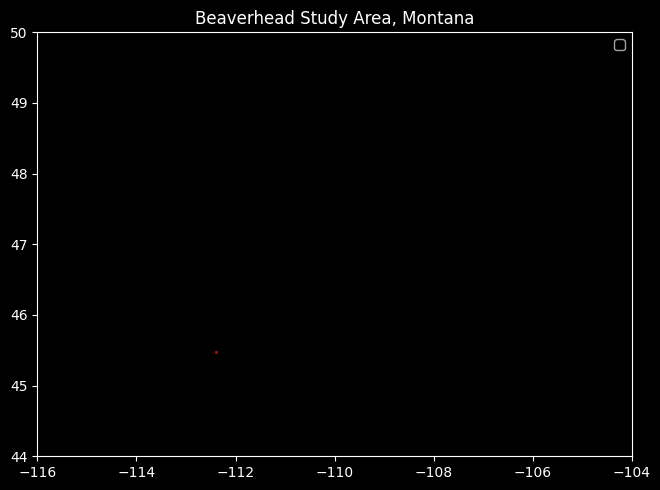

AOI bounds [W, S, E, N]: [-112.418, 45.445, -112.353, 45.49]


In [2]:
# Beaverhead study area locator map
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box
import tomllib
from pathlib import Path

with open(Path("beaverhead_config.toml"), "rb") as f:
    _cfg = tomllib.load(f)

bounds = _cfg["bounds"]  # [W, S, E, N]
aoi_gdf = gpd.GeoDataFrame(geometry=[box(*bounds)], crs="EPSG:4326")

try:
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    usa = world[world.name == "United States of America"]
except Exception:
    usa = None

fig, ax = plt.subplots(figsize=(8, 5))
if usa is not None:
    usa.plot(ax=ax, color="#f0f0f0", edgecolor="gray")
aoi_gdf.plot(ax=ax, color="red", alpha=0.7, label="Beaverhead AOI")
ax.set_xlim(-116, -104)
ax.set_ylim(44, 50)
ax.set_title("Beaverhead Study Area, Montana")
ax.legend()
plt.tight_layout()
plt.show()
print(f"AOI bounds [W, S, E, N]: {bounds}")

## 4. Artifact output tree

All outputs land under `{out_dir}`:

```
{out_dir}/
├── dem_bounds_1m.tif          ← NB02: DEM from local 3DEP STAC
├── streams_bounds.tif         ← NB02: NHD AND NDWI stream mask
├── rem_bounds.tif             ← NB02: Relative Elevation Model
├── fields_bounds.fgb          ← NB02: fields clipped to bounds
├── fields_stratified.fgb      ← NB03: fields + strata column
├── fields_pattern.fgb         ← NB03: fields + pattern column
├── gridmet/{FID}.parquet      ← NB04: daily met per field
├── et_join/{FID}.parquet      ← NB04: gridmet + PTjpl joined
└── partition/{FID}.parquet    ← NB05: partitioned ET components
```

## 5. Operational tools

The notebooks focus on the analytical workflow. Four operational capabilities are available via CLI and Python API that are not covered in depth here but are essential for production runs.

In [3]:
# Operational Callout: STAC catalog build
# Build a local 3DEP STAC catalog for Montana before running the REM workflow:
#
#   handily stac build --states MT --stac-dir ~/data/handily/stac/3dep_1m
#   handily stac extend --states MT --stac-dir ~/data/handily/stac/3dep_1m
#
# Operational Callout: AOI tiling
# For statewide or multi-watershed runs, tile a field layer into
# spatially-manageable AOI polygons before running bounds per tile:
#
#   handily aoi --fields fields.gpkg --out aoi_tiles.fgb
print("STAC CLI: handily stac build --states MT --stac-dir {stac_dir}")
print("AOI CLI:  handily aoi --fields {fields_path} --out aoi_tiles.fgb")

STAC CLI: handily stac build --states MT --stac-dir {stac_dir}
AOI CLI:  handily aoi --fields {fields_path} --out aoi_tiles.fgb


In [4]:
# Operational Callout: Bucket sync
# After Earth Engine exports complete, sync results locally:
# 
#   handily sync --config beaverhead_config.toml --subdir ptjpl
#   handily sync --config beaverhead_config.toml --subdir irrmapper
#
# Or use the Python API:
# from handily.bucket import sync_bucket_to_local
# sync_bucket_to_local(bucket="wudr", bucket_prefix="handily",
#     local_root=config.local_data_root, subdir="ptjpl", dry_run=True)
print("Sync CLI: handily sync --config beaverhead_config.toml --subdir ptjpl")

Sync CLI: handily sync --config beaverhead_config.toml --subdir ptjpl


In [5]:
# Operational Callout: QGIS integration
# After all workflow steps are complete, update the QGIS project and generate layer files:
# 
#   handily qgis update --config beaverhead_config.toml
#   handily qgis qlr --config beaverhead_config.toml
#
# This updates {config.qgis_project} with all raster and vector outputs
# and generates a .qlr drag-and-drop layer definition file.
print("QGIS CLI: handily qgis update --config beaverhead_config.toml")
print("QGIS CLI: handily qgis qlr --config beaverhead_config.toml")

QGIS CLI: handily qgis update --config beaverhead_config.toml
QGIS CLI: handily qgis qlr --config beaverhead_config.toml


> **Repo Capability — Notebook 1 (Introduction)**
> Modules exercised: `handily.config`
> Key functions: `HandilyConfig.from_dict()`
> CLI equivalents: `handily stac build`, `handily sync`, `handily bounds`, `handily aoi`, `handily qgis update`

> **Artifacts Produced**
> - `{out_dir}/dem_bounds_1m.tif` — DEM from local 3DEP STAC (NB02)
> - `{out_dir}/streams_bounds.tif` — NHD AND NDWI stream mask (NB02)
> - `{out_dir}/rem_bounds.tif` — Relative Elevation Model (NB02)
> - `{out_dir}/fields_bounds.fgb` — fields clipped to bounds with REM stats (NB02)
> - `{out_dir}/fields_stratified.fgb` — fields + strata column (NB03)
> - `{out_dir}/fields_pattern.fgb` — fields + pattern column (NB03)
> - `{out_dir}/gridmet/{FID}.parquet` — daily met per field (NB04)
> - `{out_dir}/et_join/{FID}.parquet` — gridmet + PTjpl joined (NB04)
> - `{out_dir}/partition/{FID}.parquet` — partitioned ET components (NB05)

## 5. Environment setup

From the repo root:

```bash
pip install -e .
```

Earth Engine + GCS credentials are required for IrrMapper/PT-JPL exports:

```bash
earthengine authenticate
gcloud auth application-default login
```

## 6. Configuration

Example configuration: `examples/beaverhead/beaverhead_config.toml`.

In [6]:
import tomllib
from pathlib import Path

# Load the example configuration
config_path = Path("beaverhead_config.toml")

with open(config_path, "rb") as f:
    config = tomllib.load(f)

# Display key sections
print("=== Project Identification ===")
print(f"Project name: {config.get('project_name')}")
print(f"Bucket prefix: {config.get('bucket_prefix')}")
print(f"Local data root: {config.get('local_data_root')}")

print("=== AOI Bounds ===")
bounds = config.get('bounds', [])
print(f"West, South, East, North: {bounds}")

print("=== Key Paths ===")
print(f"Fields: {config.get('fields_path')}")
print(f"Flowlines: {config.get('flowlines_local_dir')}")
print(f"Output dir: {config.get('out_dir')}")

=== Project Identification ===
Project name: beaverhead
Bucket prefix: handily
Local data root: ~/data/IrrigationGIS/handily
=== AOI Bounds ===
West, South, East, North: [-112.418, 45.445, -112.353, 45.49]
=== Key Paths ===
Fields: ~/data/IrrigationGIS/Montana/statewide_irrigation_dataset/statewide_irrigation_dataset_15FEB2024.shp
Flowlines: ~/data/IrrigationGIS/boundaries/wbd/NHD_H_Montana_State_Shape/Shape
Output dir: ~/data/IrrigationGIS/handily/handily/beaverhead/outputs/


### Configuration keys (high level)

- Project + storage: `project_name`, `bucket_prefix`, `local_data_root`, `et_bucket`
- Inputs + AOI: `fields_path`, `flowlines_local_dir`, `ndwi_dir`, `stac_dir`, `bounds`
- Step toggles: `run_rem`, `run_stratify`, `run_irrmapper`, `run_pattern`, `run_met`, `run_et`, `run_join`, `run_partition`
- Key params: `ndwi_threshold`, `rem_threshold`, `ptjpl_start_yr`, `ptjpl_end_yr`, `met_start`, `met_end`

## 7. Sanity check

Confirm paths, AOI bounds, and step flags in the TOML config before running the workflow.

In [7]:
import os

def check_path(name, path):
    """Check if a path exists and report status."""
    expanded = os.path.expanduser(path) if path else None
    exists = os.path.exists(expanded) if expanded else False
    status = "OK" if exists else "MISSING"
    print(f"[{status}] {name}: {path}")
    return exists

print("=== Checking Input Paths ===")
check_path("Fields shapefile", config.get('fields_path'))
check_path("Flowlines directory", config.get('flowlines_local_dir'))
check_path("NDWI directory", config.get('ndwi_dir'))
check_path("STAC catalog", config.get('stac_dir'))

print("\n=== Checking Output Directory ===")
check_path("Output directory", config.get('out_dir'))

=== Checking Input Paths ===
[MISSING] Fields shapefile: ~/data/IrrigationGIS/Montana/statewide_irrigation_dataset/statewide_irrigation_dataset_15FEB2024.shp
[MISSING] Flowlines directory: ~/data/IrrigationGIS/boundaries/wbd/NHD_H_Montana_State_Shape/Shape
[MISSING] NDWI directory: ~/data/IrrigationGIS/handily/ndwi/beaverhead/
[MISSING] STAC catalog: ~/data/IrrigationGIS/handily/stac/3dep_1m/

=== Checking Output Directory ===
[MISSING] Output directory: ~/data/IrrigationGIS/handily/handily/beaverhead/outputs/


False

In [8]:
# Check Earth Engine authentication
try:
    import ee
    ee.Initialize()
    print("[OK] Earth Engine authenticated")
except Exception as e:
    print(f"[WARNING] Earth Engine not authenticated: {e}")
    print("Run 'earthengine authenticate' to set up access")

[OK] Earth Engine authenticated


In [9]:
# Check handily installation
try:
    import handily
    print(f"[OK] handily version: {handily.__version__}")
except ImportError:
    print("[ERROR] handily not installed")
    print("Run 'pip install handily' or install from source")

[OK] handily version: 0.1.0


**Next**: [Notebook 02 - Terrain Analysis](02_terrain_analysis.ipynb)